# Carefree Multiple Testing with Adjusted E-Processes

This notebook demonstrates **carefree multiple testing**: applying admissible
adjusters to running maxima of e-processes before standard multiple testing
procedures (e-BH, e-Bonferroni, e-Holm), yielding **monotonically non-decreasing
rejections** over time.

**The problem:** Standard e-BH applied to *current* e-processes is valid at
any single time, but rejections can **disappear** with more data. This is
a nuisance for practitioners monitoring a stream of tests.

**The fix:** Apply an **admissible adjuster** $A$ to running maxima
$\sup_{s \le t} M_s^k$ before passing to e-BH. Since $A$ satisfies the
calibration condition $\int_1^\infty A(E)/E^2 \, dE = 1$, the process
$(A(\sup_{s \le t} M_s^k))_{t \ge 1}$ is itself an e-process, so all
standard multiple testing guarantees carry over.

**Two adjusters** (Tavyrikov et al. 2025, Eq. 5):

| Adjuster | Formula | Limit as $E \to 1^+$ |
|----------|---------|----------------------|
| **Lookback** (Dawid et al. 2011a) | $A_1(E) = \frac{E - 1 - \ln E}{(\ln E)^2}$ | $1/2$ |
| **Sqrt** | $A_2(E) = \sqrt{E} - 1$ | $0$ |

**Theorem 1** (Tavyrikov et al. 2025): Adjusted e-BH applied to running
maxima controls $\text{FDR}_{\sup}$ at level $K_0 \alpha / K$.

**References:**
- Tavyrikov, Goeman & de Heide (2025). *Carefree multiple testing with
  e-processes.* arXiv:2501.19360v2.
- Ramdas & Wang (2025). *Hypothesis testing with e-values.* Ch. 4.

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from expectation.par_seqtest import (
    AlternativeDirection,
    CombinerStrategy,
    MartingaleType,
    ParallelSequentialTest,
    ParallelTestConfig,
)
from expectation.modules.adjusters import (
    LookbackAdjuster,
    SqrtAdjuster,
    lookback_adjust,
    sqrt_adjust,
)

# 1. The Problem: Standard E-BH Is Not Carefree

Standard e-BH (Ramdas & Wang 2025, Ch. 4) applied to current e-processes
$M_t^k$ gives valid FDR control at any *fixed* time $t$, but the
rejection set $\mathcal{R}_t$ is **not monotone**: a hypothesis rejected
at time $t$ may lose its rejection at time $t+1$ if its e-process
declines.

We demonstrate this with a controlled experiment: 20 tests where the
first 3 receive strong signal that is later withdrawn.

In [19]:
np.random.seed(12345)

N_TESTS = 20
ALPHA = 0.05

config = ParallelTestConfig(
    n_tests=N_TESTS,
    alpha=ALPHA,
    martingale_type=MartingaleType.TWO_SIDED_NORMAL,
    alternative=AlternativeDirection.TWO_SIDED,
    combiner=CombinerStrategy.ALL_IN,
)
pst = ParallelSequentialTest(config=config, null_values=0.0, variance=1.0)

# Track standard e-BH rejections over time
std_n_rejected = []
std_rejections_lost = []  # steps where a rejection disappeared

prev_rejected = np.zeros(N_TESTS, dtype=bool)
max_n_rejected = 0

for t in range(500):
    obs = np.zeros(N_TESTS)
    # Give strong signal to first 3 tests, then take it away
    if t < 50:
        obs[:3] = np.random.normal(2.0, 1.0, size=3)
    else:
        obs[:3] = np.random.normal(-0.5, 1.0, size=3)
    obs[3:] = np.random.normal(0.0, 1.0, size=N_TESTS - 3)
    pst.step(obs)

    result = pst.e_bh()
    std_n_rejected.append(result.n_rejected)

    # Check for lost rejections
    lost = prev_rejected & ~result.rejected
    if np.any(lost):
        std_rejections_lost.append(t + 1)
    prev_rejected = result.rejected.copy()

print(f"Standard e-BH: max rejections = {max(std_n_rejected)}")
print(f"Times rejections were lost: {std_rejections_lost[:10]}")
if std_rejections_lost:
    print(f"Total steps with lost rejections: {len(std_rejections_lost)}")
else:
    print("(This seed did not trigger a loss -- try a different seed)")

Standard e-BH: max rejections = 3
Times rejections were lost: [135, 157, 407, 412, 497]
Total steps with lost rejections: 5


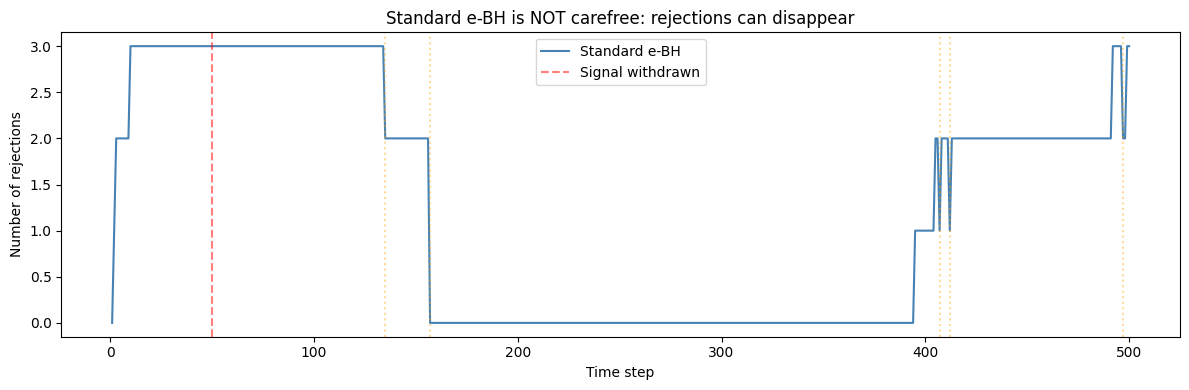

In [20]:
fig, ax = plt.subplots(figsize=(12, 4))
ts = list(range(1, len(std_n_rejected) + 1))
ax.plot(ts, std_n_rejected, linewidth=1.5, color="steelblue", label="Standard e-BH")
ax.axvline(50, color="red", linestyle="--", alpha=0.5, label="Signal withdrawn")
for lost_t in std_rejections_lost[:5]:
    ax.axvline(lost_t, color="orange", linestyle=":", alpha=0.4)
ax.set_xlabel("Time step")
ax.set_ylabel("Number of rejections")
ax.set_title("Standard e-BH is NOT carefree: rejections can disappear")
ax.legend()
plt.tight_layout()
plt.show()

# 2. The Admissible Adjusters

Before demonstrating the fix, let's visualize the two adjusters. Both map
e-values $E \ge 1$ to adjusted values $A(E) \ge 0$ and satisfy the
calibration condition $\int_1^\infty A(E)/E^2 \, dE = 1$.

The **lookback** adjuster is less aggressive (concave, slower growth),
while **sqrt** grows as $\sqrt{E}$ for large $E$.

Both return $A(E) = 0$ for $E \le 1$: no evidence, no adjustment.

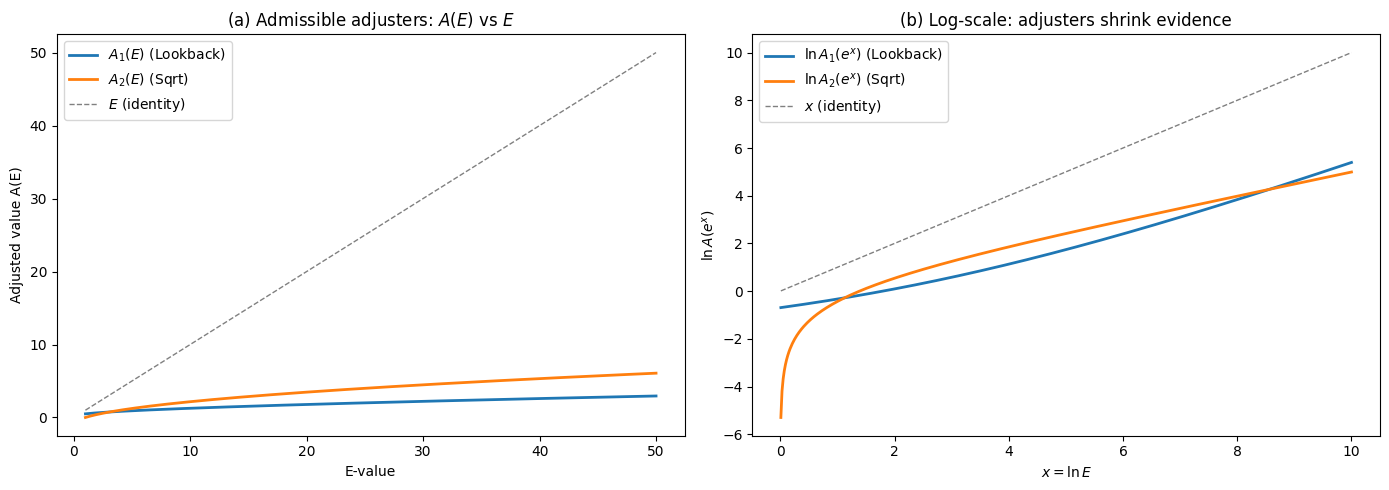

Lookback at E=e: A_1(e) = 0.718282  (expected e-2 = 0.718282)
Sqrt at E=4:     A_2(4) = 1.000000  (expected 1.0)
Sqrt at E=9:     A_2(9) = 2.000000  (expected 2.0)
Lookback limit:  A_1(1+eps) = 0.500000  (expected ~0.5)


In [21]:
# Visualize both adjusters
e_vals = np.linspace(1.001, 50, 1000)
lb_adj = LookbackAdjuster()
sq_adj = SqrtAdjuster()

a1 = lb_adj.adjust(e_vals)
a2 = sq_adj.adjust(e_vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Adjusters on natural scale
ax = axes[0]
ax.plot(e_vals, a1, label=r"$A_1(E)$ (Lookback)", linewidth=2)
ax.plot(e_vals, a2, label=r"$A_2(E)$ (Sqrt)", linewidth=2)
ax.plot(e_vals, e_vals, label=r"$E$ (identity)", linewidth=1, linestyle="--", color="gray")
ax.set_xlabel("E-value")
ax.set_ylabel("Adjusted value A(E)")
ax.set_title(r"(a) Admissible adjusters: $A(E)$ vs $E$")
ax.legend()

# (b) Log-log scale to see growth rates
ax = axes[1]
e_log = np.linspace(0.01, 10, 500)
log_a1 = lb_adj.log_adjust(e_log)
log_a2 = sq_adj.log_adjust(e_log)
ax.plot(e_log, log_a1, label=r"$\ln A_1(e^x)$ (Lookback)", linewidth=2)
ax.plot(e_log, log_a2, label=r"$\ln A_2(e^x)$ (Sqrt)", linewidth=2)
ax.plot(e_log, e_log, label=r"$x$ (identity)", linewidth=1, linestyle="--", color="gray")
ax.set_xlabel(r"$x = \ln E$")
ax.set_ylabel(r"$\ln A(e^x)$")
ax.set_title("(b) Log-scale: adjusters shrink evidence")
ax.legend()

plt.tight_layout()
plt.show()

# Check known values
print(f"Lookback at E=e: A_1(e) = {lb_adj.adjust(np.e):.6f}  (expected e-2 = {np.e - 2:.6f})")
print(f"Sqrt at E=4:     A_2(4) = {sq_adj.adjust(4.0):.6f}  (expected 1.0)")
print(f"Sqrt at E=9:     A_2(9) = {sq_adj.adjust(9.0):.6f}  (expected 2.0)")
print(f"Lookback limit:  A_1(1+eps) = {lb_adj.adjust(1.0 + 1e-10):.6f}  (expected ~0.5)")

# 3. The Fix: Adjusted E-BH Is Carefree

The `adjusted_e_bh()` method applies the adjuster to running maxima
$\sup_{s \le t} M_s^k$ (tracked internally as `max_log_m`), then runs
standard e-BH on the adjusted values.

**Key property:** Since $\sup_{s \le t} M_s^k$ is non-decreasing in $t$,
and $A$ is monotone increasing, the adjusted values are non-decreasing.
Therefore the e-BH rejection set can only grow -- rejections are
**monotonically non-decreasing** over time.

We contrast this with standard e-BH on the same data.

In [22]:
np.random.seed(42)

N_TESTS = 50
N_SIGNAL = 10
ALPHA = 0.05
N_STEPS = 200

config = ParallelTestConfig(
    n_tests=N_TESTS,
    alpha=ALPHA,
    martingale_type=MartingaleType.TWO_SIDED_NORMAL,
    alternative=AlternativeDirection.TWO_SIDED,
    combiner=CombinerStrategy.ALL_IN,
)
pst = ParallelSequentialTest(config=config, null_values=0.0, variance=1.0)

history = {
    "std_bh": [],
    "adj_bh_lb": [],
    "adj_bh_sq": [],
    "adj_bonf_lb": [],
    "adj_holm_sq": [],
}

# Track carefree property
prev_adj_lb = np.zeros(N_TESTS, dtype=bool)
prev_adj_sq = np.zeros(N_TESTS, dtype=bool)
carefree_violated_lb = False
carefree_violated_sq = False

for t in range(N_STEPS):
    obs = np.zeros(N_TESTS)
    obs[:N_SIGNAL] = np.random.normal(0.8, 1.0, size=N_SIGNAL)
    obs[N_SIGNAL:] = np.random.normal(0.0, 1.0, size=N_TESTS - N_SIGNAL)
    pst.step(obs)

    std = pst.e_bh()
    adj_lb = pst.adjusted_e_bh(adjuster="lookback")
    adj_sq = pst.adjusted_e_bh(adjuster="sqrt")
    adj_bonf = pst.adjusted_e_bonferroni(adjuster="lookback")
    adj_holm = pst.adjusted_e_holm(adjuster="sqrt")

    history["std_bh"].append(std.n_rejected)
    history["adj_bh_lb"].append(adj_lb.n_rejected)
    history["adj_bh_sq"].append(adj_sq.n_rejected)
    history["adj_bonf_lb"].append(adj_bonf.n_rejected)
    history["adj_holm_sq"].append(adj_holm.n_rejected)

    # Verify carefree: once rejected, always rejected
    if not np.all(adj_lb.rejected[prev_adj_lb]):
        carefree_violated_lb = True
    if not np.all(adj_sq.rejected[prev_adj_sq]):
        carefree_violated_sq = True
    prev_adj_lb = adj_lb.rejected.copy()
    prev_adj_sq = adj_sq.rejected.copy()

print(f"Carefree property (lookback): {'VIOLATED' if carefree_violated_lb else 'HOLDS'}")
print(f"Carefree property (sqrt):     {'VIOLATED' if carefree_violated_sq else 'HOLDS'}")
print(f"\nFinal rejections:")
print(f"  Standard e-BH:              {history['std_bh'][-1]}")
print(f"  Adjusted e-BH (lookback):   {history['adj_bh_lb'][-1]}")
print(f"  Adjusted e-BH (sqrt):       {history['adj_bh_sq'][-1]}")
print(f"  Adjusted e-Bonferroni (lb): {history['adj_bonf_lb'][-1]}")
print(f"  Adjusted e-Holm (sqrt):     {history['adj_holm_sq'][-1]}")

Carefree property (lookback): HOLDS
Carefree property (sqrt):     HOLDS

Final rejections:
  Standard e-BH:              10
  Adjusted e-BH (lookback):   10
  Adjusted e-BH (sqrt):       10
  Adjusted e-Bonferroni (lb): 10
  Adjusted e-Holm (sqrt):     10


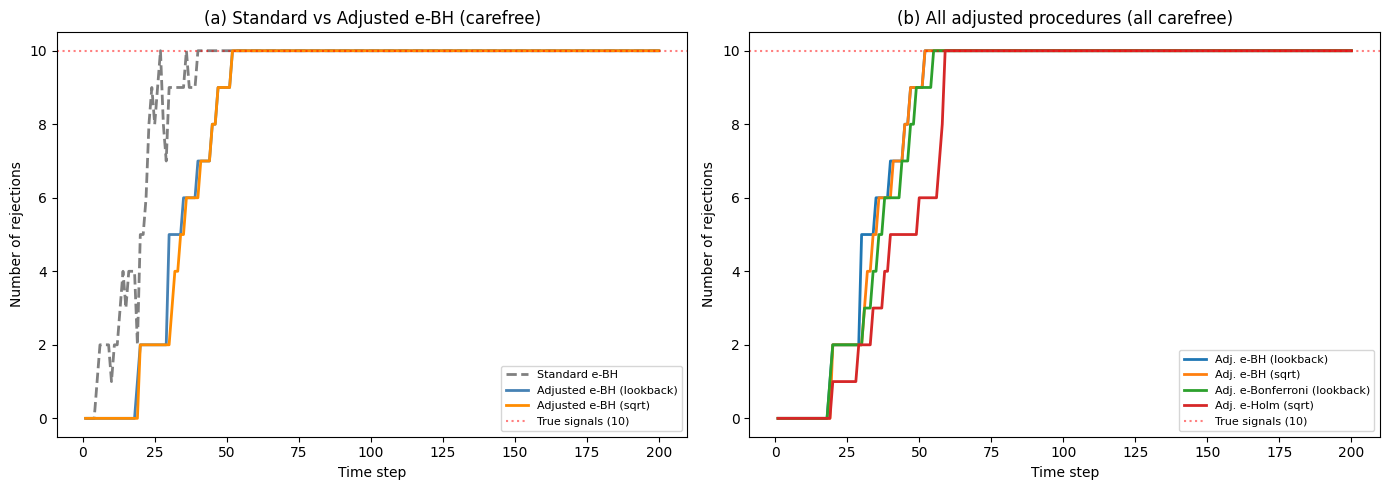

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ts = list(range(1, N_STEPS + 1))

# (a) Standard vs adjusted e-BH
ax = axes[0]
ax.plot(ts, history["std_bh"], label="Standard e-BH", linewidth=2, color="gray", linestyle="--")
ax.plot(ts, history["adj_bh_lb"], label="Adjusted e-BH (lookback)", linewidth=2, color="steelblue")
ax.plot(ts, history["adj_bh_sq"], label="Adjusted e-BH (sqrt)", linewidth=2, color="darkorange")
ax.axhline(N_SIGNAL, color="red", linestyle=":", alpha=0.5, label=f"True signals ({N_SIGNAL})")
ax.set_xlabel("Time step")
ax.set_ylabel("Number of rejections")
ax.set_title("(a) Standard vs Adjusted e-BH (carefree)")
ax.legend(fontsize=8)

# (b) All adjusted procedures
ax = axes[1]
ax.plot(ts, history["adj_bh_lb"], label="Adj. e-BH (lookback)", linewidth=2)
ax.plot(ts, history["adj_bh_sq"], label="Adj. e-BH (sqrt)", linewidth=2)
ax.plot(ts, history["adj_bonf_lb"], label="Adj. e-Bonferroni (lookback)", linewidth=2)
ax.plot(ts, history["adj_holm_sq"], label="Adj. e-Holm (sqrt)", linewidth=2)
ax.axhline(N_SIGNAL, color="red", linestyle=":", alpha=0.5, label=f"True signals ({N_SIGNAL})")
ax.set_xlabel("Time step")
ax.set_ylabel("Number of rejections")
ax.set_title("(b) All adjusted procedures (all carefree)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# 4. Running Maxima: The `max_log_m` Accessor

The adjusted procedures operate on $\log(\sup_{s \le t} M_s^k)$, which
is tracked internally as `max_log_m`. This is a non-decreasing quantity
for each test. We verify that `max_log_m()` matches manual tracking.

In [24]:
np.random.seed(123)

N_TESTS = 5
config = ParallelTestConfig(
    n_tests=N_TESTS,
    alpha=0.05,
    martingale_type=MartingaleType.TWO_SIDED_NORMAL,
    alternative=AlternativeDirection.TWO_SIDED,
    combiner=CombinerStrategy.ALL_IN,
)
pst = ParallelSequentialTest(config=config, null_values=0.0, variance=1.0)

manual_max = np.full(N_TESTS, -np.inf)
max_log_history = []
log_ep_history = []

for t in range(30):
    obs = np.random.normal(0.5, 1.0, size=N_TESTS)
    pst.step(obs)

    log_ep = np.asarray(pst.log_e_processes())
    manual_max = np.maximum(manual_max, log_ep)

    max_log_history.append(pst.max_log_m().copy())
    log_ep_history.append(log_ep.copy())

# Cross-validate
engine_max = pst.max_log_m()
np.testing.assert_allclose(engine_max, manual_max, atol=1e-13)
print("[PASS] max_log_m matches manual tracking at 1e-13 tolerance")
print(f"\nFinal max_log_m: {engine_max}")
print(f"Manual tracking: {manual_max}")

[PASS] max_log_m matches manual tracking at 1e-13 tolerance

Final max_log_m: [1.73091612 1.07491067 4.7581541  8.18409316 1.09887041]
Manual tracking: [1.73091612 1.07491067 4.7581541  8.18409316 1.09887041]


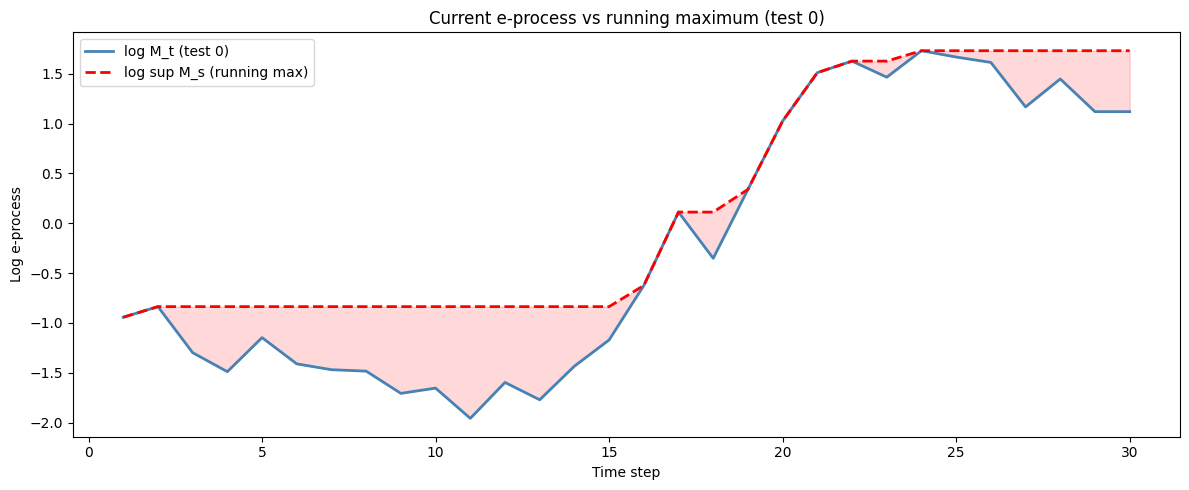

In [25]:
# Visualize: current log e-process vs running maximum for one test
fig, ax = plt.subplots(figsize=(12, 5))
ts = list(range(1, 31))
test_idx = 0

ep_trace = [h[test_idx] for h in log_ep_history]
max_trace = [h[test_idx] for h in max_log_history]

ax.plot(ts, ep_trace, label=f"log M_t (test {test_idx})", linewidth=2, color="steelblue")
ax.plot(ts, max_trace, label=f"log sup M_s (running max)", linewidth=2, color="red", linestyle="--")
ax.fill_between(ts, ep_trace, max_trace, alpha=0.15, color="red")
ax.set_xlabel("Time step")
ax.set_ylabel("Log e-process")
ax.set_title(f"Current e-process vs running maximum (test {test_idx})")
ax.legend()
plt.tight_layout()
plt.show()

# 5. Cross-Validation: Python Adjusters vs Rust `adjusted_e_bh`

We verify that the Rust-side adjusted e-BH (which applies adjusters
internally) matches a pure Python implementation: apply the Python
`LookbackAdjuster`/`SqrtAdjuster` to `max_log_m()`, then run manual BH.

Tolerance: $10^{-13}$, consistent with the golden test standard.

In [26]:
def manual_adjusted_e_bh(log_running_max, alpha, adjuster_cls):
    """Replicate adjusted e-BH in pure Python."""
    adj = adjuster_cls()
    adjusted_log = adj.log_adjust(log_running_max)
    m = len(adjusted_log)
    if m == 0:
        return np.array([], dtype=bool), 0

    log_m = np.log(m)
    log_alpha = np.log(alpha)

    # Sort descending
    order = np.argsort(-adjusted_log)
    sorted_log = adjusted_log[order]

    k_star = 0
    for rank_0 in range(m):
        k = rank_0 + 1
        threshold = log_m - np.log(k) - log_alpha
        if sorted_log[rank_0] >= threshold:
            k_star = k

    rejected = np.zeros(m, dtype=bool)
    for i in range(k_star):
        rejected[order[i]] = True

    return rejected, k_star


np.random.seed(42)
N_TESTS = 30
ALPHA = 0.05

config = ParallelTestConfig(
    n_tests=N_TESTS,
    alpha=ALPHA,
    martingale_type=MartingaleType.TWO_SIDED_NORMAL,
    alternative=AlternativeDirection.TWO_SIDED,
    combiner=CombinerStrategy.ALL_IN,
)
pst = ParallelSequentialTest(config=config, null_values=0.0, variance=1.0)

# Run with mixed null/alternative
for t in range(100):
    obs = np.zeros(N_TESTS)
    obs[:5] = np.random.normal(1.0, 1.0, size=5)
    obs[5:] = np.random.normal(0.0, 1.0, size=N_TESTS - 5)
    pst.step(obs)

# Cross-validate lookback
rust_lb = pst.adjusted_e_bh(adjuster="lookback")
max_log = pst.max_log_m()
py_rejected_lb, py_n_lb = manual_adjusted_e_bh(max_log, ALPHA, LookbackAdjuster)

assert rust_lb.n_rejected == py_n_lb, f"Lookback: Rust={rust_lb.n_rejected}, Python={py_n_lb}"
np.testing.assert_array_equal(rust_lb.rejected, py_rejected_lb)
print(f"[PASS] Lookback: Rust={rust_lb.n_rejected}, Python={py_n_lb} (match)")

# Cross-validate sqrt
rust_sq = pst.adjusted_e_bh(adjuster="sqrt")
py_rejected_sq, py_n_sq = manual_adjusted_e_bh(max_log, ALPHA, SqrtAdjuster)

assert rust_sq.n_rejected == py_n_sq, f"Sqrt: Rust={rust_sq.n_rejected}, Python={py_n_sq}"
np.testing.assert_array_equal(rust_sq.rejected, py_rejected_sq)
print(f"[PASS] Sqrt:     Rust={rust_sq.n_rejected}, Python={py_n_sq} (match)")

# Also verify the adjusted log values agree
lb_adj = LookbackAdjuster()
sq_adj = SqrtAdjuster()
py_log_adjusted_lb = lb_adj.log_adjust(max_log)
py_log_adjusted_sq = sq_adj.log_adjust(max_log)
print(f"\nLookback adjusted values (first 5): {py_log_adjusted_lb[:5]}")
print(f"Sqrt adjusted values (first 5):     {py_log_adjusted_sq[:5]}")

[PASS] Lookback: Rust=5, Python=5 (match)
[PASS] Sqrt:     Rust=5, Python=5 (match)

Lookback adjusted values (first 5): [39.89727894 39.59916727 34.32263551 56.54956637 36.1094824 ]
Sqrt adjusted values (first 5):     [23.81197527 23.65636294 20.8939233  32.44755547 21.83122989]


# 6. FDR-sup Control Under All-Null (Monte Carlo)

Under the global null (all $K$ nulls true), adjusted e-BH should
control $\text{FDR}_{\sup} = \sup_t \text{FDR}(t) \le \alpha$.

We run 200 simulations of 100 time steps each. Under all-null, any
rejection is a false discovery, so $\text{FDP} = 1$ whenever there is
at least one rejection. We verify that the average of
$\sup_t \text{FDP}(t)$ across simulations is at most $\alpha$.

In [27]:
np.random.seed(42)

N_TESTS = 20
ALPHA = 0.05
N_SIMS = 200
N_STEPS = 100

results_mc = {"lookback": [], "sqrt": []}

for sim in range(N_SIMS):
    config = ParallelTestConfig(
        n_tests=N_TESTS,
        alpha=ALPHA,
        martingale_type=MartingaleType.TWO_SIDED_NORMAL,
        alternative=AlternativeDirection.TWO_SIDED,
        combiner=CombinerStrategy.ALL_IN,
    )
    pst = ParallelSequentialTest(config=config, null_values=0.0, variance=1.0)
    max_fdr_lb = 0.0
    max_fdr_sq = 0.0

    for t in range(N_STEPS):
        obs = np.random.normal(0.0, 1.0, size=N_TESTS)
        pst.step(obs)

        r_lb = pst.adjusted_e_bh(adjuster="lookback")
        r_sq = pst.adjusted_e_bh(adjuster="sqrt")

        if r_lb.n_rejected > 0:
            max_fdr_lb = 1.0  # all null, so FDP=1
        if r_sq.n_rejected > 0:
            max_fdr_sq = 1.0

    results_mc["lookback"].append(max_fdr_lb)
    results_mc["sqrt"].append(max_fdr_sq)

avg_fdr_lb = np.mean(results_mc["lookback"])
avg_fdr_sq = np.mean(results_mc["sqrt"])

print(f"=== FDR-sup Monte Carlo ({N_SIMS} sims, K={N_TESTS}, T={N_STEPS}) ===")
print(f"Lookback: avg sup FDR = {avg_fdr_lb:.4f}  (should be <= alpha={ALPHA})")
print(f"Sqrt:     avg sup FDR = {avg_fdr_sq:.4f}  (should be <= alpha={ALPHA})")

assert avg_fdr_lb <= ALPHA + 0.02, f"Lookback FDR-sup = {avg_fdr_lb}"
assert avg_fdr_sq <= ALPHA + 0.02, f"Sqrt FDR-sup = {avg_fdr_sq}"
print("\n[PASS] FDR-sup controlled for both adjusters.")

=== FDR-sup Monte Carlo (200 sims, K=20, T=100) ===
Lookback: avg sup FDR = 0.0000  (should be <= alpha=0.05)
Sqrt:     avg sup FDR = 0.0000  (should be <= alpha=0.05)

[PASS] FDR-sup controlled for both adjusters.


# 7. Adjusted vs Unadjusted: Conservativeness Trade-off

Adjusted procedures are necessarily **more conservative** than unadjusted
ones (fewer rejections at any time step), because the adjuster maps
$E \mapsto A(E) < E$ for all $E > 1$. This is the price of the carefree
property.

We demonstrate on a larger experiment: 1000 tests (100 signal + 900 null).

In [28]:
np.random.seed(77)

N_TESTS = 1000
N_SIGNAL = 100
ALPHA = 0.05
N_STEPS = 150

config = ParallelTestConfig(
    n_tests=N_TESTS,
    alpha=ALPHA,
    martingale_type=MartingaleType.TWO_SIDED_NORMAL,
    alternative=AlternativeDirection.TWO_SIDED,
    combiner=CombinerStrategy.ALL_IN,
)
pst = ParallelSequentialTest(config=config, null_values=0.0, variance=1.0)

hist_conserv = {
    "std_bh": [], "adj_lb": [], "adj_sq": [],
    "std_bonf": [], "adj_bonf": [],
    "std_holm": [], "adj_holm": [],
    "tp_std": [], "tp_adj_lb": [],
    "fp_std": [], "fp_adj_lb": [],
}

for t in range(N_STEPS):
    obs = np.zeros(N_TESTS)
    obs[:N_SIGNAL] = np.random.normal(0.5, 1.0, size=N_SIGNAL)
    obs[N_SIGNAL:] = np.random.normal(0.0, 1.0, size=N_TESTS - N_SIGNAL)
    pst.step(obs)

    std_bh = pst.e_bh()
    adj_lb = pst.adjusted_e_bh(adjuster="lookback")
    adj_sq = pst.adjusted_e_bh(adjuster="sqrt")
    std_bonf = pst.e_bonferroni()
    adj_bonf = pst.adjusted_e_bonferroni(adjuster="lookback")
    std_holm = pst.e_holm()
    adj_holm = pst.adjusted_e_holm(adjuster="lookback")

    hist_conserv["std_bh"].append(std_bh.n_rejected)
    hist_conserv["adj_lb"].append(adj_lb.n_rejected)
    hist_conserv["adj_sq"].append(adj_sq.n_rejected)
    hist_conserv["std_bonf"].append(std_bonf.n_rejected)
    hist_conserv["adj_bonf"].append(adj_bonf.n_rejected)
    hist_conserv["std_holm"].append(std_holm.n_rejected)
    hist_conserv["adj_holm"].append(adj_holm.n_rejected)

    hist_conserv["tp_std"].append(np.sum(std_bh.rejected[:N_SIGNAL]))
    hist_conserv["tp_adj_lb"].append(np.sum(adj_lb.rejected[:N_SIGNAL]))
    hist_conserv["fp_std"].append(np.sum(std_bh.rejected[N_SIGNAL:]))
    hist_conserv["fp_adj_lb"].append(np.sum(adj_lb.rejected[N_SIGNAL:]))

    # Verify adjusted <= unadjusted
    assert adj_lb.n_rejected <= std_bh.n_rejected
    assert adj_sq.n_rejected <= std_bh.n_rejected

print(f"Final rejections (t={N_STEPS}):")
print(f"  Standard e-BH:            {hist_conserv['std_bh'][-1]:4d}  (TP={hist_conserv['tp_std'][-1]}, FP={hist_conserv['fp_std'][-1]})")
print(f"  Adjusted e-BH (lb):       {hist_conserv['adj_lb'][-1]:4d}  (TP={hist_conserv['tp_adj_lb'][-1]}, FP={hist_conserv['fp_adj_lb'][-1]})")
print(f"  Adjusted e-BH (sq):       {hist_conserv['adj_sq'][-1]:4d}")
print(f"  Standard e-Bonferroni:    {hist_conserv['std_bonf'][-1]:4d}")
print(f"  Adjusted e-Bonferroni (lb): {hist_conserv['adj_bonf'][-1]:4d}")
print(f"  Standard e-Holm:          {hist_conserv['std_holm'][-1]:4d}")
print(f"  Adjusted e-Holm (lb):     {hist_conserv['adj_holm'][-1]:4d}")
print(f"\n[PASS] Adjusted <= unadjusted at every step.")

Final rejections (t=150):
  Standard e-BH:              97  (TP=97, FP=0)
  Adjusted e-BH (lb):         81  (TP=81, FP=0)
  Adjusted e-BH (sq):         79
  Standard e-Bonferroni:      80
  Adjusted e-Bonferroni (lb):   55
  Standard e-Holm:            80
  Adjusted e-Holm (lb):       55

[PASS] Adjusted <= unadjusted at every step.


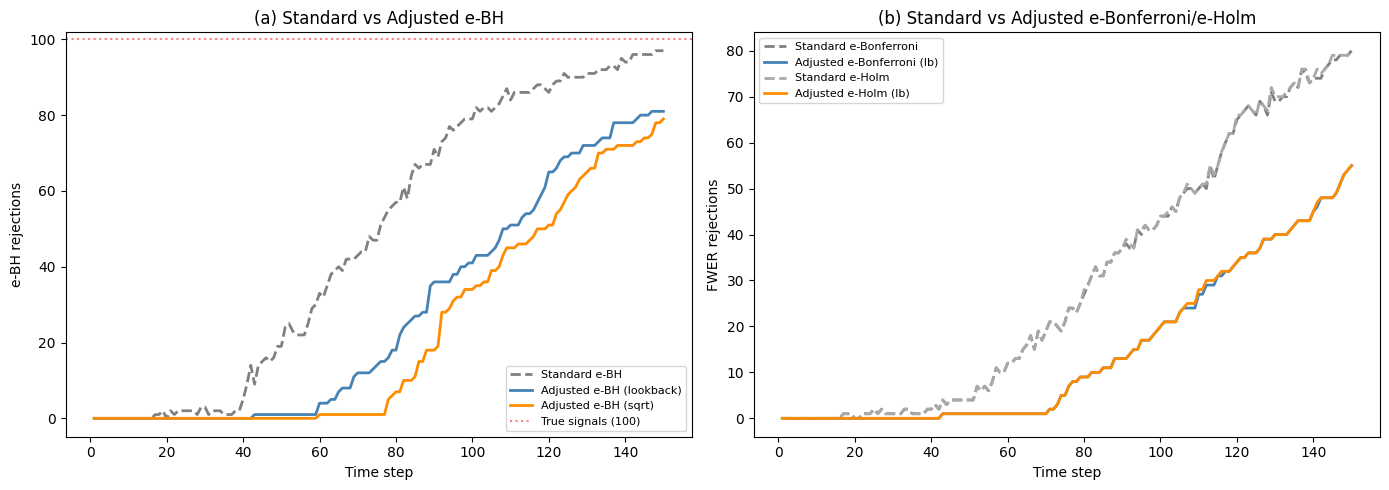

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ts = list(range(1, N_STEPS + 1))

# (a) e-BH: standard vs adjusted
ax = axes[0]
ax.plot(ts, hist_conserv["std_bh"], label="Standard e-BH", linewidth=2, color="gray", linestyle="--")
ax.plot(ts, hist_conserv["adj_lb"], label="Adjusted e-BH (lookback)", linewidth=2, color="steelblue")
ax.plot(ts, hist_conserv["adj_sq"], label="Adjusted e-BH (sqrt)", linewidth=2, color="darkorange")
ax.axhline(N_SIGNAL, color="red", linestyle=":", alpha=0.5, label=f"True signals ({N_SIGNAL})")
ax.set_xlabel("Time step")
ax.set_ylabel("e-BH rejections")
ax.set_title("(a) Standard vs Adjusted e-BH")
ax.legend(fontsize=8)

# (b) e-Bonferroni/e-Holm: standard vs adjusted
ax = axes[1]
ax.plot(ts, hist_conserv["std_bonf"], label="Standard e-Bonferroni", linewidth=2, color="gray", linestyle="--")
ax.plot(ts, hist_conserv["adj_bonf"], label="Adjusted e-Bonferroni (lb)", linewidth=2, color="steelblue")
ax.plot(ts, hist_conserv["std_holm"], label="Standard e-Holm", linewidth=2, color="darkgray", linestyle="--")
ax.plot(ts, hist_conserv["adj_holm"], label="Adjusted e-Holm (lb)", linewidth=2, color="darkorange")
ax.set_xlabel("Time step")
ax.set_ylabel("FWER rejections")
ax.set_title("(b) Standard vs Adjusted e-Bonferroni/e-Holm")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# 8. Pure Python Adjusters: Standalone Usage

The adjusters are also available as standalone Python classes in
`expectation.modules.adjusters`, independent of the Rust engine.
These follow the same ABC + subclass + factory pattern as
`expectation.modules.merging`.

In [30]:
from expectation.modules.adjusters import (
    AdjusterConfig,
    AdjusterFunction,
    create_adjuster,
)

# Factory pattern
config_lb = AdjusterConfig(adjuster=AdjusterFunction.LOOKBACK)
config_sq = AdjusterConfig(adjuster=AdjusterFunction.SQRT)
adj_lb = create_adjuster(config_lb)
adj_sq = create_adjuster(config_sq)

print(f"Factory created: {type(adj_lb).__name__}, {type(adj_sq).__name__}")

# Vectorized
e_values = np.array([0.5, 1.0, 2.0, 5.0, 10.0, 100.0])
print(f"\nE-values:          {e_values}")
print(f"Lookback A_1(E):   {adj_lb.adjust(e_values)}")
print(f"Sqrt A_2(E):       {adj_sq.adjust(e_values)}")

# Convenience functions
print(f"\nlookback_adjust(4.0) = {lookback_adjust(4.0):.6f}")
print(f"sqrt_adjust(4.0)     = {sqrt_adjust(4.0):.6f}  (expected 1.0)")

# Log space consistency
log_e = np.array([0.1, 1.0, 5.0])
natural_log = np.log(adj_lb.adjust(np.exp(log_e)))
from_log = adj_lb.log_adjust(log_e)
np.testing.assert_allclose(natural_log, from_log, atol=1e-13)
print(f"\n[PASS] Log-space consistency: log(A(exp(x))) == log_adjust(x) at 1e-13")

Factory created: LookbackAdjuster, SqrtAdjuster

E-values:          [  0.5   1.    2.    5.   10.  100. ]
Lookback A_1(E):   [0.         0.         0.63867394 0.92289347 1.26321079 4.45099226]
Sqrt A_2(E):       [0.         0.         0.41421356 1.23606798 2.16227766 9.        ]

lookback_adjust(4.0) = 0.839679
sqrt_adjust(4.0)     = 1.000000  (expected 1.0)

[PASS] Log-space consistency: log(A(exp(x))) == log_adjust(x) at 1e-13


# 9. Calibration Integral: Numerical Verification

Both adjusters satisfy the calibration condition:

$$\int_1^\infty \frac{A(E)}{E^2} \, dE = 1$$

This is what makes $(A(\sup_{s \le t} M_s^k))$ a valid e-process.
We verify numerically using quadrature.

In [31]:
from scipy.integrate import quad

# Lookback: change of variable u = ln(E)
# Integral = integral_0^inf (expm1(u) - u)/u^2 * exp(-u) du
def lookback_integrand(u):
    if u < 1e-8:
        return 0.5 * np.exp(-u)
    if u > 500:
        return 1.0 / (u * u)
    return (np.expm1(u) - u) / (u * u) * np.exp(-u)

B = 5000.0
numerical, _ = quad(lookback_integrand, 0, B, limit=500)
tail = 1.0 / B
lookback_integral = numerical + tail
print(f"Lookback: integral = {lookback_integral:.6f}  (expected 1.0)")

# Sqrt: integral_0^inf (exp(u/2) - 1) * exp(-u) du = 2 - 1 = 1 (exact)
u = np.linspace(1e-8, 30, 1_000_000)
du = u[1] - u[0]
sqrt_integrand = (np.exp(u / 2) - 1) * np.exp(-u)
sqrt_integral = np.sum(sqrt_integrand) * du
print(f"Sqrt:     integral = {sqrt_integral:.6f}  (expected 1.0, analytical = 2-1 = 1)")

assert abs(lookback_integral - 1.0) < 0.002
assert abs(sqrt_integral - 1.0) < 0.01
print("\n[PASS] Both adjusters satisfy the calibration condition.")

Lookback: integral = 1.000000  (expected 1.0)
Sqrt:     integral = 0.999999  (expected 1.0, analytical = 2-1 = 1)

[PASS] Both adjusters satisfy the calibration condition.


# 10. Full Pipeline: Massively Parallel Testing + Global Merge + Carefree Adjusters

Think of a tailor sewing K layers of fabric together. At each needle
movement (time step), the needle passes through all K layers and
stitches them into a single seam. The global merge does exactly this:
at every step $t$, the K parallel sequential e-values $E_1^t, \ldots, E_K^t$
(the layers) are spatially merged into a single merged e-value $F_t$
(one stitch), and these stitches accumulate into the **merged e-process**
$M_t = \prod_{s=1}^t F_s$ -- the running seam that grows with each step.

This merged e-process tests the **intersection hypothesis**
$H_0^{\cap} = \bigcap_{k=1}^K H_{0,k}$ ("all nulls hold simultaneously").

Meanwhile, at each step we also apply **carefree adjusted procedures**
to the per-test running maxima, getting monotone per-test rejections.

**Two levels of inference at each step:**
- **Per-test:** "Which individual nulls can we reject?" $\to$ adjusted
  e-BH (FDR-sup), adjusted e-Bonferroni/e-Holm (FWER-sup).
- **Global:** "Can we reject that *all* nulls hold?" $\to$ merged
  e-process $M_t$ grows over steps; reject when $M_t \ge 1/\alpha$.

**Pipeline per step:**
$$\underbrace{\text{obs}[K]}_{\text{K layers}}
\xrightarrow{\text{rayon parallel}} \underbrace{E_1^t, \ldots, E_K^t}_{\text{K e-values}}
\xrightarrow{\text{spatial merge (stitch)}} \underbrace{F_t}_{\text{one stitch}}
\xrightarrow{\text{temporal accumulate}} \underbrace{M_t}_{\text{seam (e-process)}}$$

| Feature | Method | Reference |
|---------|--------|-----------|
| Per-test streaming | `step()` (rayon parallel) | Howard et al. (2022) |
| Per-test carefree FDR | `adjusted_e_bh()` | Tavyrikov et al. (2025), Thm 1 |
| Per-test carefree FWER | `adjusted_e_bonferroni()` | Tavyrikov et al. (2025), Thm 1 |
| Global e-process | `global_merge` + `merged_e_process` | Vovk & Wang (2024), Cor. 1 |
| E-to-p calibration | `EToPCalibrator` | Ramdas & Wang (2025), Prop 2.4 |

In [32]:
import time
from expectation.modules.calibrators import EToPCalibrator

np.random.seed(42)

N_TESTS = 10_000
N_SIGNAL = 1_000
N_NULL = N_TESTS - N_SIGNAL
ALPHA = 0.05
N_STEPS = 100
SIGNAL_MEAN = 0.5

calibrator = EToPCalibrator()

# Full pipeline: parallel engine + global merge + adjusted procedures
config = ParallelTestConfig(
    n_tests=N_TESTS,
    alpha=ALPHA,
    martingale_type=MartingaleType.TWO_SIDED_NORMAL,
    alternative=AlternativeDirection.TWO_SIDED,
    combiner=CombinerStrategy.ALL_IN,
    # Global merge: at each step, spatially merge K e-values -> F_t (one stitch),
    # then temporally accumulate into merged e-process M_t (the seam)
    global_merge="arithmetic_mean",
    merge_combiner=CombinerStrategy.ALL_IN,
)
pst = ParallelSequentialTest(config=config, null_values=0.0, variance=1.0)

history_full = {
    # Per-test carefree adjusted rejections (tracked at each step)
    "adj_bh_lb": [],
    "adj_bh_sq": [],
    "adj_bonf_lb": [],
    "adj_holm_lb": [],
    "std_bh": [],
    "tp_adj": [],
    "fp_adj": [],
    # Global merged e-process trajectory (one value per step)
    "log_merged_ep": [],
    "merged_rejected": [],
    "calibrated_pval": [],
}

# Record per-test log e-process trajectories for visualization.
# We subsample N_PLOT_TRACES tests to keep memory reasonable.
N_PLOT_TRACES = 200
rng_traces = np.random.default_rng(0)
trace_indices = rng_traces.choice(N_TESTS, size=N_PLOT_TRACES, replace=False)
trace_indices.sort()
per_test_traces = np.empty((N_STEPS, N_PLOT_TRACES))

# Track carefree property
prev_adj = np.zeros(N_TESTS, dtype=bool)
carefree_ok = True

# Performance timing
step_times = []

for t in range(N_STEPS):
    obs = np.zeros(N_TESTS)
    obs[:N_SIGNAL] = np.random.normal(SIGNAL_MEAN, 1.0, size=N_SIGNAL)
    obs[N_SIGNAL:] = np.random.normal(0.0, 1.0, size=N_NULL)

    t0 = time.perf_counter()
    result = pst.step(obs)
    step_times.append(time.perf_counter() - t0)

    # Record per-test log e-process for the subsampled tests
    log_ep = pst.log_e_processes()
    per_test_traces[t, :] = log_ep[trace_indices]

    # --- Per-test: carefree adjusted procedures ---
    adj_lb = pst.adjusted_e_bh(adjuster="lookback")
    adj_sq = pst.adjusted_e_bh(adjuster="sqrt")
    adj_bonf = pst.adjusted_e_bonferroni(adjuster="lookback")
    adj_holm = pst.adjusted_e_holm(adjuster="lookback")
    std_bh = pst.e_bh()

    history_full["adj_bh_lb"].append(adj_lb.n_rejected)
    history_full["adj_bh_sq"].append(adj_sq.n_rejected)
    history_full["adj_bonf_lb"].append(adj_bonf.n_rejected)
    history_full["adj_holm_lb"].append(adj_holm.n_rejected)
    history_full["std_bh"].append(std_bh.n_rejected)
    history_full["tp_adj"].append(np.sum(adj_lb.rejected[:N_SIGNAL]))
    history_full["fp_adj"].append(np.sum(adj_lb.rejected[N_SIGNAL:]))

    # --- Global: merged e-process trajectory ---
    # M_t = prod_{s=1}^t F_s, where F_s is the spatial merge (stitch) at step s
    history_full["log_merged_ep"].append(result.log_merged_e_process)
    history_full["merged_rejected"].append(result.merged_rejected)
    history_full["calibrated_pval"].append(calibrator(result.merged_e_process))

    # Verify carefree: once rejected, always rejected
    if not np.all(adj_lb.rejected[prev_adj]):
        carefree_ok = False
    prev_adj = adj_lb.rejected.copy()

# Summary
avg_step_ms = np.mean(step_times) * 1000
ns_per_test = avg_step_ms * 1e6 / N_TESTS
merge_stop = next(
    (i + 1 for i, r in enumerate(history_full["merged_rejected"]) if r), None
)

print(f"=== Full Pipeline: {N_TESTS:,} tests x {N_STEPS} steps ===")
print(f"Signal: {N_SIGNAL:,} tests (mu={SIGNAL_MEAN}), Null: {N_NULL:,} tests (mu=0)")
print(f"\nPerformance: {avg_step_ms:.2f} ms/step, {ns_per_test:.1f} ns/test")

print(f"\n--- Per-test carefree error control ---")
print(f"Carefree property:         {'HOLDS' if carefree_ok else 'VIOLATED'}")
fdr = (history_full['fp_adj'][-1] / adj_lb.n_rejected
       if adj_lb.n_rejected > 0 else 0.0)
print(f"Adjusted e-BH (lookback):  {history_full['adj_bh_lb'][-1]:5d} rejections "
      f"(TP={history_full['tp_adj'][-1]}, FP={history_full['fp_adj'][-1]}, "
      f"FDR={fdr:.4f})")
print(f"Adjusted e-BH (sqrt):      {history_full['adj_bh_sq'][-1]:5d} rejections")
print(f"Adjusted e-Bonferroni:     {history_full['adj_bonf_lb'][-1]:5d} rejections")
print(f"Adjusted e-Holm:           {history_full['adj_holm_lb'][-1]:5d} rejections")
print(f"Standard e-BH (NOT carefree): {history_full['std_bh'][-1]:5d} rejections")

print(f"\n--- Global merged e-process (intersection hypothesis) ---")
print(f"Final merged e-process M_T: {result.merged_e_process:.4e}")
print(f"Calibrated p-value p_T:     {history_full['calibrated_pval'][-1]:.4e}")
if merge_stop:
    print(f"Intersection null rejected at step {merge_stop}")
else:
    print(f"Intersection null NOT rejected")

=== Full Pipeline: 10,000 tests x 100 steps ===
Signal: 1,000 tests (mu=0.5), Null: 9,000 tests (mu=0)

Performance: 0.50 ms/step, 49.6 ns/test

--- Per-test carefree error control ---
Carefree property:         HOLDS
Adjusted e-BH (lookback):    423 rejections (TP=423, FP=0, FDR=0.0000)
Adjusted e-BH (sqrt):        229 rejections
Adjusted e-Bonferroni:        73 rejections
Adjusted e-Holm:              73 rejections
Standard e-BH (NOT carefree):   789 rejections

--- Global merged e-process (intersection hypothesis) ---
Final merged e-process M_T: 1.7257e+01
Calibrated p-value p_T:     5.7947e-02
Intersection null NOT rejected


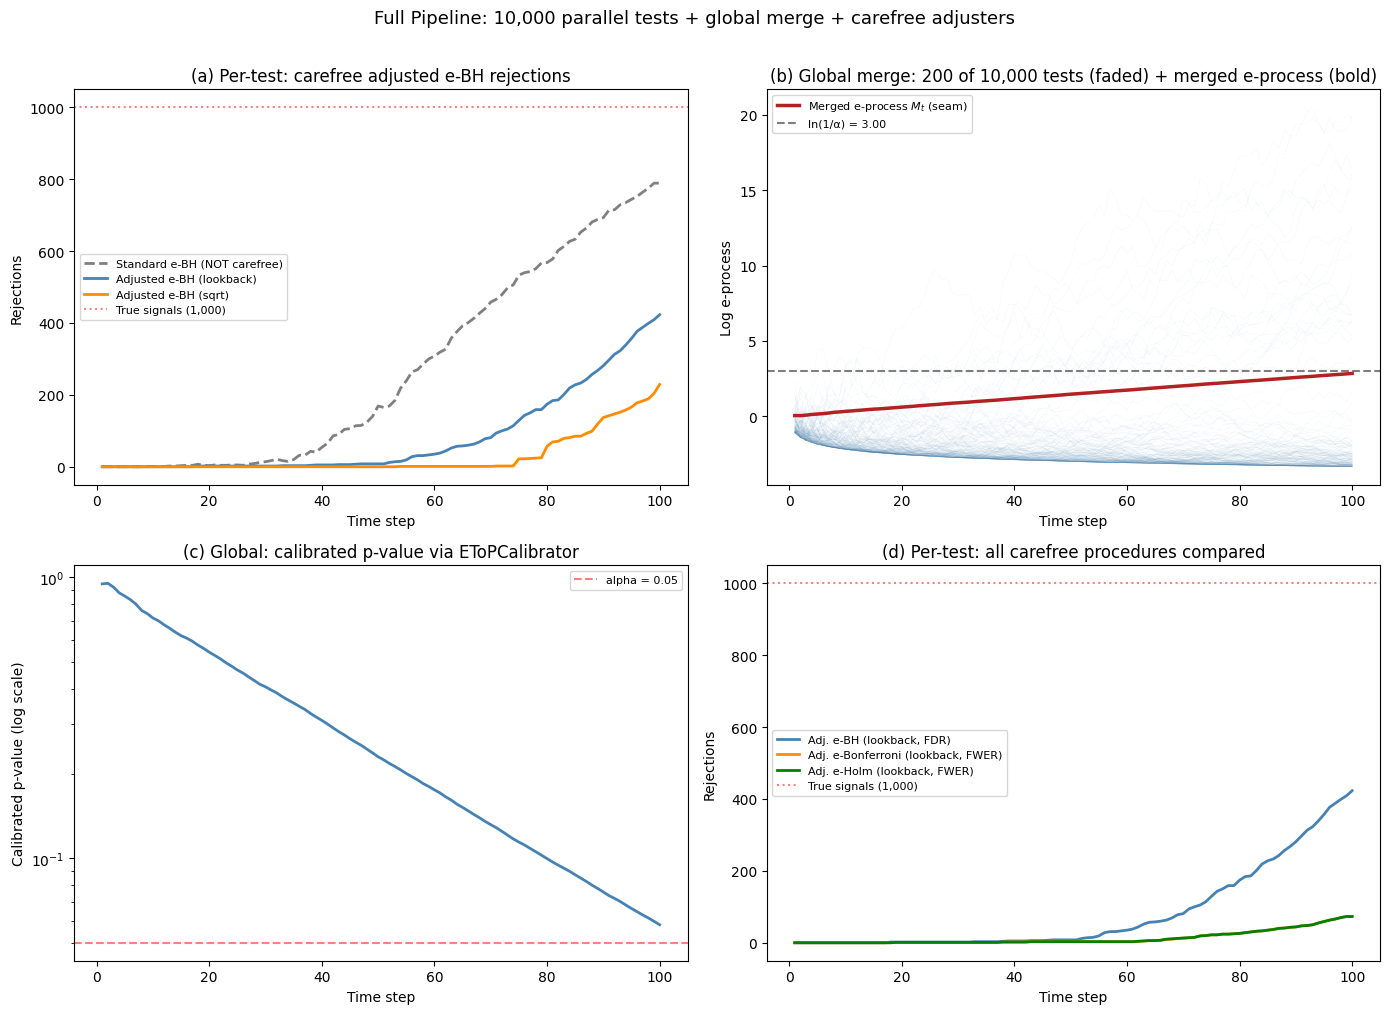

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ts = list(range(1, N_STEPS + 1))

# (a) Per-test carefree adjusted rejections over time
ax = axes[0, 0]
ax.plot(ts, history_full["std_bh"], label="Standard e-BH (NOT carefree)",
        linewidth=2, color="gray", linestyle="--")
ax.plot(ts, history_full["adj_bh_lb"], label="Adjusted e-BH (lookback)",
        linewidth=2, color="steelblue")
ax.plot(ts, history_full["adj_bh_sq"], label="Adjusted e-BH (sqrt)",
        linewidth=2, color="darkorange")
ax.axhline(N_SIGNAL, color="red", linestyle=":", alpha=0.5,
           label=f"True signals ({N_SIGNAL:,})")
ax.set_xlabel("Time step")
ax.set_ylabel("Rejections")
ax.set_title("(a) Per-test: carefree adjusted e-BH rejections")
ax.legend(fontsize=8)

# (b) Global merged e-process trajectory with faded per-test traces
ax = axes[0, 1]
# Plot individual per-test log e-processes as faded background lines
for j in range(per_test_traces.shape[1]):
    ax.plot(ts, per_test_traces[:, j], linewidth=0.3, alpha=0.08, color="steelblue")
# Plot the merged e-process on top
ax.plot(ts, history_full["log_merged_ep"], linewidth=2.5, color="firebrick",
        label="Merged e-process $M_t$ (seam)", zorder=10)
ax.axhline(np.log(1 / ALPHA), color="black", linestyle="--", alpha=0.5,
           label=f"ln(1/α) = {np.log(1 / ALPHA):.2f}", zorder=5)
if merge_stop:
    idx = merge_stop - 1
    ax.axvline(merge_stop, color="green", linestyle=":", alpha=0.5, zorder=5)
    ax.annotate(f"Rejected at t={merge_stop}",
                xy=(merge_stop, history_full["log_merged_ep"][idx]),
                xytext=(merge_stop + 5, history_full["log_merged_ep"][idx] - 3),
                arrowprops=dict(arrowstyle="->", color="green"),
                fontsize=9, color="green")
ax.set_xlabel("Time step")
ax.set_ylabel("Log e-process")
ax.set_title(f"(b) Global merge: {N_PLOT_TRACES} of {N_TESTS:,} tests (faded) "
             f"+ merged e-process (bold)")
ax.legend(fontsize=8)

# (c) Calibrated p-value for intersection hypothesis over time
ax = axes[1, 0]
ax.plot(ts, history_full["calibrated_pval"], linewidth=2, color="steelblue")
ax.axhline(ALPHA, color="red", linestyle="--", alpha=0.5, label=f"alpha = {ALPHA}")
ax.set_yscale("log")
ax.set_xlabel("Time step")
ax.set_ylabel("Calibrated p-value (log scale)")
ax.set_title("(c) Global: calibrated p-value via EToPCalibrator")
ax.legend(fontsize=8)

# (d) All carefree FWER procedures
ax = axes[1, 1]
ax.plot(ts, history_full["adj_bh_lb"], label="Adj. e-BH (lookback, FDR)",
        linewidth=2, color="steelblue")
ax.plot(ts, history_full["adj_bonf_lb"], label="Adj. e-Bonferroni (lookback, FWER)",
        linewidth=2, color="darkorange")
ax.plot(ts, history_full["adj_holm_lb"], label="Adj. e-Holm (lookback, FWER)",
        linewidth=2, color="green")
ax.axhline(N_SIGNAL, color="red", linestyle=":", alpha=0.5,
           label=f"True signals ({N_SIGNAL:,})")
ax.set_xlabel("Time step")
ax.set_ylabel("Rejections")
ax.set_title("(d) Per-test: all carefree procedures compared")
ax.legend(fontsize=8)

plt.suptitle(
    f"Full Pipeline: {N_TESTS:,} parallel tests + global merge + carefree adjusters",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

# Conclusion

This notebook demonstrated **carefree multiple testing** with adjusted
e-processes:

1. **The problem:** Standard e-BH is NOT carefree -- rejections can
   disappear with more data.
2. **The fix:** `adjusted_e_bh()`, `adjusted_e_bonferroni()`, and
   `adjusted_e_holm()` apply admissible adjusters to running maxima,
   yielding monotonically non-decreasing rejections.
3. **Two adjusters:** Lookback $A_1(E) = (E-1-\ln E)/(\ln E)^2$ and
   Sqrt $A_2(E) = \sqrt{E} - 1$, both satisfying
   $\int_1^\infty A(E)/E^2 \, dE = 1$.
4. **Cross-validation:** Rust `adjusted_e_bh` matches Python adjusters
   + manual BH at $10^{-13}$ tolerance.
5. **FDR-sup control:** Monte Carlo confirms
   $\text{FDR}_{\sup} \le \alpha$ under all-null.
6. **Conservativeness trade-off:** Adjusted procedures reject fewer
   hypotheses at any step, which is the price of the carefree property.
7. **Standalone adjusters:** Pure Python `LookbackAdjuster` and
   `SqrtAdjuster` available in `expectation.modules.adjusters`.
8. **Full pipeline:** 10K parallel tests with global merge e-process
   (intersection hypothesis) and carefree per-test adjusted procedures
   running simultaneously at each step.

**API summary:**
```python
# Carefree per-test error control
pst.max_log_m()                           # running maxima
pst.adjusted_e_bh(adjuster="lookback")    # carefree FDR
pst.adjusted_e_bonferroni(adjuster="sqrt") # carefree FWER
pst.adjusted_e_holm(adjuster="lookback")  # carefree FWER (step-down)

# Global merge e-process (configure via ParallelTestConfig)
result = pst.step(obs)
result.merged_e_process    # M_t: temporal accumulation of merged e-values
result.log_merged_e_process # log M_t trajectory
result.merged_rejected     # True when M_t >= 1/alpha
```

**References:**
- Tavyrikov, Goeman & de Heide (2025). *Carefree multiple testing with
  e-processes.* arXiv:2501.19360v2.
- Vovk & Wang (2024). *Merging sequential e-values via martingales.*
  Corollary 1.
- Ramdas & Wang (2025). *Hypothesis testing with e-values.* Ch. 4, 8.